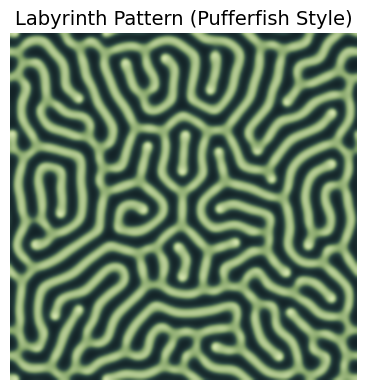

In [22]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.colors import LinearSegmentedColormap

def laplacian(Z):
    # 空間の広がり（ラプラシアン）を上下左右のセルから計算
    return (np.roll(Z, 1, axis=0) + np.roll(Z, -1, axis=0) +
            np.roll(Z, 1, axis=1) + np.roll(Z, -1, axis=1) - 4 * Z)

# ★ここが重要！ ラビリンス（迷路）模様を作るパラメータ
Du, Dv = 0.16, 0.08  # 拡散係数はそのまま
F, k = 0.042, 0.061  # Fとkのバランスを変えることで迷路模様になる
iterations = 10000   # 模様が画面全体に広がるようにステップ数を増やす
size = 200           # 網目状の細かさを表現するためにサイズを拡大

# 初期状態のセットアップ
U = np.ones((size, size))
V = np.zeros((size, size))

# 画面全体にランダムな「種」を撒く（全体から模様を成長させるため）
np.random.seed(42) # 再現性のためのシード値
U += 0.05 * np.random.random((size, size))
V += 0.05 * np.random.random((size, size))

# 中央付近に初期のきっかけを配置
r = 20
U[size//2-r:size//2+r, size//2-r:size//2+r] = 0.50
V[size//2-r:size//2+r, size//2-r:size//2+r] = 0.25

# 時間発展の計算
for i in range(iterations):
    Lu = laplacian(U)
    Lv = laplacian(V)
    
    uvv = U * V * V
    
    U += Du * Lu - uvv + F * (1 - U)
    V += Dv * Lv + uvv - (F + k) * V

# ★画像のフグの色合いに似せたオリジナル・カラーマップを作成
colors = ["#132226", "#2c4a45", "#81a166", "#d9e8b3"] # 暗い緑〜明るい黄緑
puffer_cmap = LinearSegmentedColormap.from_list("puffer", colors)

# 画像の生成と表示
plt.figure(figsize=(4, 4))
plt.imshow(V, cmap=puffer_cmap, interpolation='bicubic')
plt.axis('off')
plt.title("Labyrinth Pattern (Pufferfish Style)", fontsize=14)
plt.tight_layout()
plt.show()

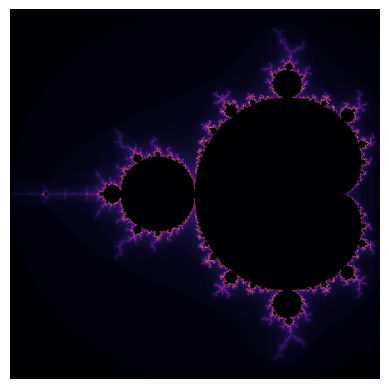

In [21]:
import numpy as np
import matplotlib.pyplot as plt

def generate_mandelbrot(width, height, x_min, x_max, y_min, y_max, max_iter):
    # 複素数平面のグリッドを作成
    x = np.linspace(x_min, x_max, width)
    y = np.linspace(y_min, y_max, height)
    X, Y = np.meshgrid(x, y)
    C = X + 1j * Y
    Z = np.zeros_like(C)
    
    # 発散するまでの繰り返し回数を記録する配列
    escape_time = np.zeros(C.shape, dtype=int)
    mask = np.ones(C.shape, dtype=bool)

    for i in range(max_iter):
        Z[mask] = Z[mask]**2 + C[mask]
        
        # 閾値（半径2）を超えたら発散とみなす
        diverged = np.abs(Z) > 2
        escape_time[diverged & mask] = i
        mask[diverged] = False

    return escape_time

# 画像の生成と表示
image = generate_mandelbrot(800, 800, -2.0, 0.5, -1.25, 1.25, 100)
plt.imshow(image, cmap='magma', extent=[-2.0, 0.5, -1.25, 1.25])
plt.axis('off')
plt.show()